# 2 Segmentation
- H5: Category-diverse customers have higher retention
- **H5**: **Category-diverse users (multi-merchant)** form a segment with higher loyalty/retention than single-merchant users, even after controlling for frequency — i.e., diversity of engagement is itself protective against churn, not just a byproduct of being an active user.

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm,skew
from scipy import stats
import datetime as dt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from itertools import combinations
%matplotlib inline

In [5]:
rfm_churn = pd.read_csv('rfm_churn.csv')
new = pd.read_csv('new_merchant_transactions.csv')
historical = pd.read_csv('historical_transactions.csv')
merchants = pd.read_csv('merchants.csv')

In [6]:
rfm_churn.head()

,card_id,recency,frequency,monetary,r,f,m,rfm,rfm points,Tier,first_purchase_date,last_purchase_date,total_orders,total_spend,days_since_last_purchase,churned_90d,AOV,recency_days
0,C_ID_00007093c1,21 days,121,64.194000,3,4,5,345,12,High tier,2017-02-14 14:00:43,2018-02-08 16:37:19,121,64.194000,19,0,0.530529,21
1,C_ID_0001238066,2 days,113,44.172385,5,4,4,544,13,Top tier,2017-09-28 22:25:14,2018-02-27 16:18:59,113,44.172385,0,0,0.390906,2
2,C_ID_0001506ef0,12 days,66,31.398121,3,4,4,344,11,High tier,2017-01-14 16:16:01,2018-02-17 12:33:56,66,31.398121,10,0,0.475729,12
3,C_ID_0001793786,125 days,102,88.780546,1,4,5,145,10,Mid-high tier,2017-01-21 10:15:21,2017-10-27 13:51:16,102,88.780546,123,1,0.870398,125
4,C_ID_000183fdda,4 days,136,65.877791,4,5,5,455,14,Top tier,2017-08-07 09:49:14,2018-02-25 20:57:08,136,65.877791,2,0,0.484396,4


## Develop category and merchant count columns

In [8]:
# unique_merchant_count 
historical['unique_merchant_count'] = (
    historical.groupby('card_id')['merchant_id']
    .transform('nunique')
)
historical['unique_merchant_count'].head()

0    55
1    55
2    55
3    55
4    55
Name: unique_merchant_count, dtype: int64

In [9]:
# category_diversity
historical['category_diversity'] = (
    historical.groupby('card_id')['merchant_category_id']
    .transform('nunique')
)
historical['category_diversity'].head()

0    18
1    18
2    18
3    18
4    18
Name: category_diversity, dtype: int64

In [10]:
historical.shape

(29112361, 16)

In [18]:
historical.head()

,authorized_flag,card_id,city_id,category_1,installments,category_3,merchant_category_id,merchant_id,month_lag,purchase_amount,purchase_date,category_2,state_id,subsector_id,unique_merchant_count,category_diversity
0,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-8,-0.703331,2017-06-25 15:33:07,1.0,16,37,55,18
1,Y,C_ID_4e6213e9bc,88,N,0,A,367,M_ID_86ec983688,-7,-0.733128,2017-07-15 12:10:45,1.0,16,16,55,18
2,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_979ed661fc,-6,-0.720386,2017-08-09 22:04:29,1.0,16,37,55,18
3,Y,C_ID_4e6213e9bc,88,N,0,A,560,M_ID_e6d5ae8ea6,-5,-0.735352,2017-09-02 10:06:26,1.0,16,34,55,18
4,Y,C_ID_4e6213e9bc,88,N,0,A,80,M_ID_e020e9b302,-11,-0.722865,2017-03-10 01:14:19,1.0,16,37,55,18


In [26]:
# develop dataset with card_id, unique_merchant_count, and category_diversity
historical_mc_count = historical[['card_id', 'unique_merchant_count', 'category_diversity']].drop_duplicates('card_id')

# merge with rfm_churn
rfm_churn = rfm_churn.merge(
    historical_mc_count,
    on='card_id',
    how='inner')

rfm_churn.head()

,card_id,recency,frequency,monetary,r,f,m,rfm,rfm points,Tier,first_purchase_date,last_purchase_date,total_orders,total_spend,days_since_last_purchase,churned_90d,AOV,recency_days,unique_merchant_count,category_diversity
0,C_ID_00007093c1,21 days,121,64.194000,3,4,5,345,12,High tier,2017-02-14 14:00:43,2018-02-08 16:37:19,121,64.194000,19,0,0.530529,21,29,18
1,C_ID_0001238066,2 days,113,44.172385,5,4,4,544,13,Top tier,2017-09-28 22:25:14,2018-02-27 16:18:59,113,44.172385,0,0,0.390906,2,65,29
2,C_ID_0001506ef0,12 days,66,31.398121,3,4,4,344,11,High tier,2017-01-14 16:16:01,2018-02-17 12:33:56,66,31.398121,10,0,0.475729,12,28,19
3,C_ID_0001793786,125 days,102,88.780546,1,4,5,145,10,Mid-high tier,2017-01-21 10:15:21,2017-10-27 13:51:16,102,88.780546,123,1,0.870398,125,119,48
4,C_ID_000183fdda,4 days,136,65.877791,4,5,5,455,14,Top tier,2017-08-07 09:49:14,2018-02-25 20:57:08,136,65.877791,2,0,0.484396,4,73,36


In [28]:
rfm_churn['unique_merchant_count'].describe()

count    319659.000000
mean         34.260340
std          30.795068
min           1.000000
25%          14.000000
50%          25.000000
75%          44.000000
max         425.000000
Name: unique_merchant_count, dtype: float64

In [30]:
rfm_churn['category_diversity'].describe()

count    319659.000000
mean         18.553496
std          11.421304
min           1.000000
25%          10.000000
50%          16.000000
75%          25.000000
max          95.000000
Name: category_diversity, dtype: float64

## EDA: Visualize unique_merchant_count & category_diversity

In [87]:
def visualize_by_churn(df, val):
    groups = df['churned_90d'].unique()

    for group in groups:
        plt.hist(
        df.loc[df["churned_90d"] == group, val],
        bins=30,
        alpha=0.5,
        density = True,
        label=f"Churned = {group}"
        )
        
    plt.xlabel(f"{val}")
    plt.ylabel("Density")
    plt.title("Frequency Density Distribution by Churn")
    plt.legend()
    plt.show()

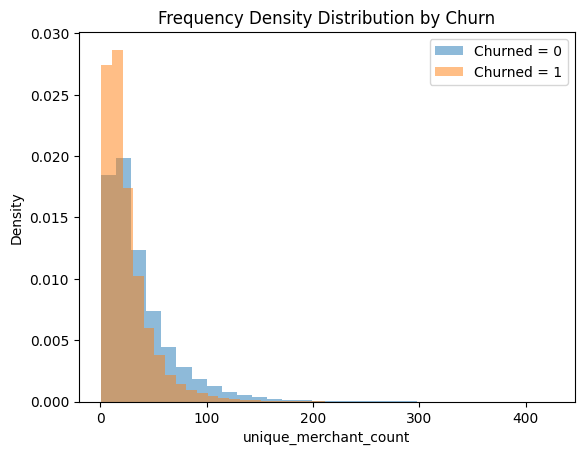

In [89]:
visualize_by_churn(rfm_churn, 'unique_merchant_count')

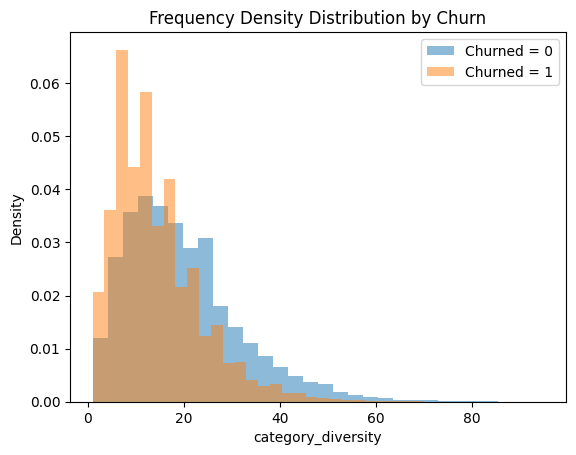

In [91]:
visualize_by_churn(rfm_churn, 'category_diversity')

### 1. Univariate comparison: low vs high diversity -> retention
- Split into **diversity tiers**
- Compare retention rates with a **chi-square test (categorical)** + **logistic regression** with just diversity as predictor

In [71]:
df = rfm_churn.copy()
 
# Define retention as the inverse of churn (1 = retained, 0 = churned)
df["retained"] = 1 - df["churned_90d"]
 
# Diversity measures to test — you have two candidates
diversity_vars = ["unique_merchant_count", "category_diversity"]
 
print("=" * 70)
print("BASIC SANITY CHECKS")
print("=" * 70)
print(df[diversity_vars + ["frequency", "churned_90d", "retained"]].describe())
print("\nMissing values:\n", df[diversity_vars + ["frequency", "churned_90d"]].isna().sum())

BASIC SANITY CHECKS
       unique_merchant_count  category_diversity      frequency  \
count          319659.000000       319659.000000  319659.000000   
mean               34.260340           18.553496      81.867543   
std                30.795068           11.421304     100.954132   
min                 1.000000            1.000000       1.000000   
25%                14.000000           10.000000      22.000000   
50%                25.000000           16.000000      48.000000   
75%                44.000000           25.000000     101.000000   
max               425.000000           95.000000    2889.000000   

         churned_90d       retained  
count  319659.000000  319659.000000  
mean        0.193441       0.806559  
std         0.394996       0.394996  
min         0.000000       0.000000  
25%         0.000000       1.000000  
50%         0.000000       1.000000  
75%         0.000000       1.000000  
max         1.000000       1.000000  

Missing values:
 unique_merchant_

In [73]:
# UNIVARIATE COMPARISON (Low vs High Diversity)
def tier_and_test(df, var, n_tiers=3, labels=None):
    """
    Split `var` into n_tiers (default = terciles), 
    --> compare retention rates across tiers with a chi-square test, and 
    --> fit a simple logistic regression of retention on the (continuous) diversity variable.
    """
    if labels is None:
        labels = ["Low", "Medium", "High"] if n_tiers == 3 else \
                  [f"Q{i+1}" for i in range(n_tiers)]
 
    tier_col = f"{var}_tier"
    # qcut handles unequal group sizes from ties; duplicates='drop' guards
    # against too many repeated values (common with count variables)
    df[tier_col] = pd.qcut(df[var], q=n_tiers, labels=labels, duplicates="drop")
 
    print(f"\n--- {var} ---")
    print(f"Tier cut points:\n{pd.qcut(df[var], q=n_tiers, duplicates='drop').cat.categories}")

    # Retention rate by tier
    summary = df.groupby(tier_col, observed=True).agg(
        n=("retained", "size"),
        retention_rate=("retained", "mean"),
        churn_rate=("churned_90d", "mean"),
        avg_diversity=(var, "mean"),
        avg_frequency=("frequency", "mean"),
    ).round(4)
    print("\nRetention by tier:")
    print(summary)
 
    # Chi-square test: tier (categorical) vs retained (categorical)
    contingency = pd.crosstab(df[tier_col], df["retained"])
    chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
    print(f"\nChi-square test (tier vs retained): chi2={chi2:.3f}, dof={dof}, p={p_chi2:.4g}")
 
    # Simple (unadjusted) logistic regression: retained ~ diversity (continuous)
    logit_simple = smf.logit(f"retained ~ {var}", data=df).fit(disp=0)
    print("\nUnadjusted logistic regression (retained ~ diversity):")
    print(logit_simple.summary2().tables[1])

    # Odds ratio for easier interpretation
    or_val = np.exp(logit_simple.params[var])
    ci = np.exp(logit_simple.conf_int().loc[var])
    print(f"Odds Ratio for {var}: {or_val:.4f}  (95% CI: {ci[0]:.4f} - {ci[1]:.4f})")
 
    return summary, chi2, p_chi2, logit_simple, tier_col

In [77]:
results_step1 = {}
for var in diversity_vars:
    summary, chi2, p_chi2, model, tier_col = tier_and_test(df, var, n_tiers=3)
    results_step1[var] = {
        "summary": summary,
        "chi2": chi2,
        "p_value": p_chi2,
        "model": model,
    }


--- unique_merchant_count ---
Tier cut points:
IntervalIndex([(0.999, 17.0], (17.0, 36.0], (36.0, 425.0]], dtype='interval[float64, right]')

Retention by tier:
                                 n  retention_rate  churn_rate  avg_diversity  \
unique_merchant_count_tier                                                      
Low                         109503          0.7243      0.2757        10.5119   
Medium                      104970          0.8153      0.1847        25.8964   
High                        105186          0.8835      0.1165        67.3302   

                            avg_frequency  
unique_merchant_count_tier                 
Low                               20.8755  
Medium                            55.7800  
High                             171.3968  

Chi-square test (tier vs retained): chi2=8799.861, dof=2, p=0

Unadjusted logistic regression (retained ~ diversity):
                          Coef.  Std.Err.           z  P>|z|    [0.025  \
Intercept          

**Unique Merchant Count**
| Tier   | n       | Retention | Churn | Avg Merchants | Avg Frequency |
|--------|---------|-----------|-------|----------------|----------------|
| Low    | 109,503 | 72.4%     | 27.6% | 10.5           | 20.9           |
| Medium | 104,970 | 81.5%     | 18.5% | 25.9           | 55.8           |
| High   | 105,186 | 88.4%     | 11.7% | 67.3           | 171.4          |

**Category Diversity**
| Tier   | n       | Retention | Churn | Avg Categories | Avg Frequency |
|--------|---------|-----------|-------|-----------------|----------------|
| Low    | 112,984 | 72.1%     | 27.9% | 8.0             | 23.5           |
| Medium | 102,367 | 81.4%     | 18.6% | 16.7            | 58.6           |
| High   | 104,308 | 89.2%     | 10.8% | 31.8            | 167.9          |

## Check the diversity vs frequency relationship
- **Correlation (Spearman, since these are likely skewed)** between diversity and frequency
- **Plot diversity by frequency decile/bucket** — if diversity increases almost linearly with frequency, that's your confounding signal

In [82]:
# Diversity vs Frequency relationship (confounding check)
for var in diversity_vars:
    rho, p_spearman = stats.spearmanr(df[var], df["frequency"])
    print(f"\nSpearman correlation ({var} vs frequency): rho={rho:.4f}, p={p_spearman:.4g}")
 
    # Also report Pearson on log1p-transformed values (both are typically
    # right-skewed count variables) as a robustness check
    r_pearson, p_pearson = stats.pearsonr(np.log1p(df[var]), np.log1p(df["frequency"]))
    print(f"Pearson correlation on log1p-transformed values: r={r_pearson:.4f}, p={p_pearson:.4g}")
 
# Bucket frequency into deciles and look at mean diversity per decile
df["frequency_decile"] = pd.qcut(df["frequency"], q=10, labels=False, duplicates="drop") + 1
 
freq_diversity_table = df.groupby("frequency_decile").agg(
    n=("frequency", "size"),
    avg_frequency=("frequency", "mean"),
    avg_unique_merchants=("unique_merchant_count", "mean"),
    avg_category_diversity=("category_diversity", "mean"),
    retention_rate=("retained", "mean"),
).round(3)
 
print("\nDiversity & retention by frequency decile:")
print(freq_diversity_table)


Spearman correlation (unique_merchant_count vs frequency): rho=0.8815, p=0
Pearson correlation on log1p-transformed values: r=0.8662, p=0

Spearman correlation (category_diversity vs frequency): rho=0.8309, p=0
Pearson correlation on log1p-transformed values: r=0.8101, p=0

Diversity & retention by frequency decile:
                      n  avg_frequency  avg_unique_merchants  \
frequency_decile                                               
1                 32634          6.161                 8.533   
2                 34081         14.484                11.606   
3                 30782         22.396                15.377   
4                 32247         31.344                19.406   
5                 31181         42.273                23.974   
6                 31848         56.116                29.246   
7                 31397         74.820                35.737   
8                 31721        102.530                44.674   
9                 31892        151.866   

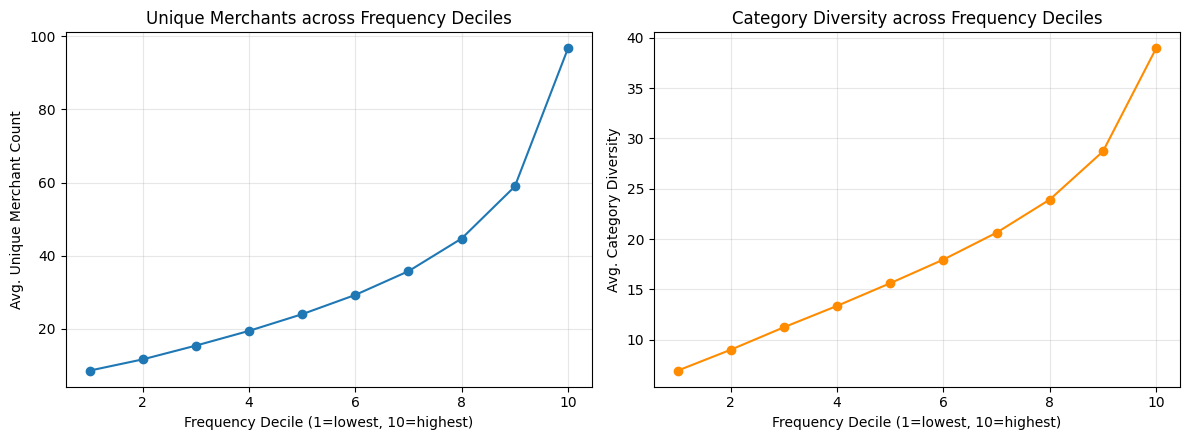

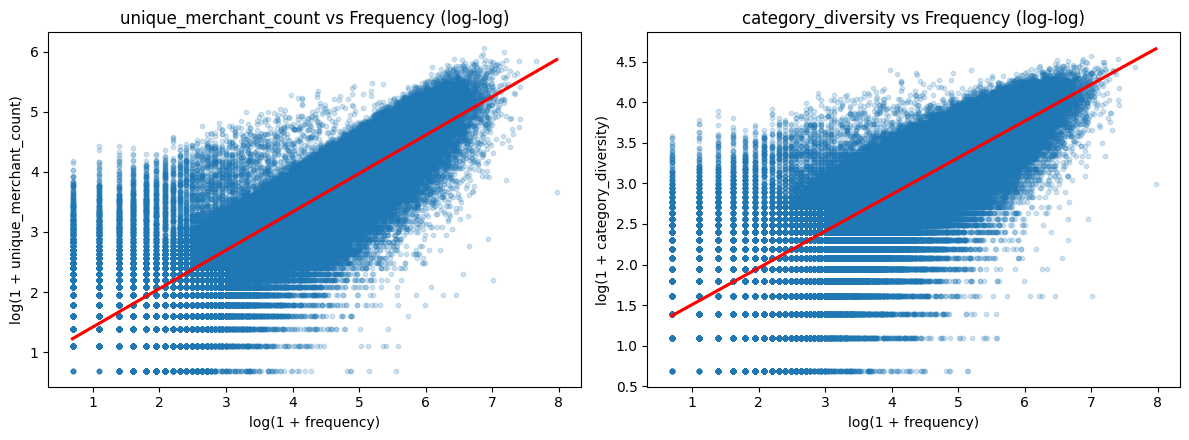

In [85]:
 # Plot: diversity trend across frequency deciles
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
 
axes[0].plot(freq_diversity_table.index, freq_diversity_table["avg_unique_merchants"],
             marker="o", label="Unique Merchants")
axes[0].set_xlabel("Frequency Decile (1=lowest, 10=highest)")
axes[0].set_ylabel("Avg. Unique Merchant Count")
axes[0].set_title("Unique Merchants across Frequency Deciles")
axes[0].grid(alpha=0.3)
 
axes[1].plot(freq_diversity_table.index, freq_diversity_table["avg_category_diversity"],
             marker="o", color="darkorange", label="Category Diversity")
axes[1].set_xlabel("Frequency Decile (1=lowest, 10=highest)")
axes[1].set_ylabel("Avg. Category Diversity")
axes[1].set_title("Category Diversity across Frequency Deciles")
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
# plt.savefig("step2_diversity_by_frequency_decile.png", dpi=150)
# plt.close()
# print("\nSaved plot: step2_diversity_by_frequency_decile.png")
plt.show()
 
# Scatter plot with regression line (log-log, since counts are skewed)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, var in zip(axes, diversity_vars):
    sns.regplot(
        x=np.log1p(df["frequency"]), y=np.log1p(df[var]),
        ax=ax, scatter_kws={"alpha": 0.2, "s": 10}, line_kws={"color": "red"}
    )
    ax.set_xlabel("log(1 + frequency)")
    ax.set_ylabel(f"log(1 + {var})")
    ax.set_title(f"{var} vs Frequency (log-log)")
plt.tight_layout()
# plt.savefig("step2_scatter_diversity_vs_frequency.png", dpi=150)
# plt.close()
# print("Saved plot: step2_scatter_diversity_vs_frequency.png")
plt.show()